<a href="https://colab.research.google.com/github/tanzeelaalvi717-blip/Protein-structure-prediction/blob/main/9F5M_Protein_prediction_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
!pip install biopython


In [61]:
!pip install biopython MDAnalysis scipy


In [96]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [97]:
BASE_PATH = ROOT # Use the ROOT path defined in cell 4xPF4mtlNDoQ

exp_path = BASE_PATH / "9f5m.cif"
af2_path = BASE_PATH / "af2_best_model.pdb"
af3_path = BASE_PATH / "af3_model.cif"
esm_path = BASE_PATH / "esmfold_model.pdb"


In [98]:
import os
print(os.listdir(BASE_PATH))


['assignment01', 'outputs', '9f5m.cif', '9f5m.pdb', '9f5m_model1.pdb']


In [99]:
import os
from pathlib import Path

# Change this folder name once; everything else uses it.
COURSE_DIR_NAME = "Bioinformatics II"  # Updated course directory name

USE_DRIVE = True # Define USE_DRIVE here
if "drive" in str(Path("/content/drive")) and os.path.exists("/content/drive") and USE_DRIVE:
    ROOT = Path("/content/drive/MyDrive") / COURSE_DIR_NAME
else:
    ROOT = Path("/content") / COURSE_DIR_NAME

ROOT.mkdir(parents=True, exist_ok=True)

DATA_DIR = ROOT / "data"
(DATA_DIR).mkdir(exist_ok=True)

OUTPUTS_DIR = ROOT / "outputs"
(OUTPUTS_DIR).mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("data:", DATA_DIR)
print("outputs:", OUTPUTS_DIR)


ROOT: /content/drive/MyDrive/Bioinformatics II
data: /content/drive/MyDrive/Bioinformatics II/data
outputs: /content/drive/MyDrive/Bioinformatics II/outputs


In [101]:
# Define PDB IDs and paths using the updated ROOT
pdb_id = "9f5m"
full_pdb = ROOT / "9f5m.pdb"
model1_pdb = ROOT / "9f5m_model1.pdb"

print("Defined full PDB path:", full_pdb)
print("Defined model 1 PDB path:", model1_pdb)


Defined full PDB path: /content/drive/MyDrive/Bioinformatics II/9f5m.pdb
Defined model 1 PDB path: /content/drive/MyDrive/Bioinformatics II/9f5m_model1.pdb


In [102]:
from Bio.PDB import PDBParser, PDBIO
from Bio.PDB.PDBIO import Select
import os

# ===== Select only MODEL 1 =====
class ModelSelect(Select):
    def accept_model(self, model):
        return model.id == 0   # MODEL 1 → id == 0 in Biopython

# --- Diagnostic check ---
if not os.path.exists(full_pdb):
    print(f"Error: The file {full_pdb} does not exist. Please ensure '9f5m.pdb' is in your course directory.")
    if os.path.exists(ROOT):
        print(f"Contents of {ROOT}:\n{os.listdir(ROOT)}")
    else:
        print(f"Root directory {ROOT} does not exist.")
    raise FileNotFoundError(f"File not found at {full_pdb}.")
# --- End Diagnostic check ---

parser = PDBParser(QUIET=True)
structure = parser.get_structure(pdb_id, str(full_pdb))

print("Number of models in structure:", len(structure))

io = PDBIO()
io.set_structure(structure)
io.save(str(model1_pdb), select=ModelSelect())

print("Saved MODEL 1 only to:", model1_pdb)


Number of models in structure: 1
Saved MODEL 1 only to: /content/drive/MyDrive/Bioinformatics II/9f5m_model1.pdb


In [103]:
!pip -q install biopython

In [104]:
!head -20 {model1_pdb}

head: cannot open '/content/drive/MyDrive/Bioinformatics' for reading: No such file or directory
head: cannot open 'II/9f5m_model1.pdb' for reading: No such file or directory


In [109]:
!pip -q install biotite

import numpy as np
import biotite.structure as struc
import biotite.structure.io.pdb as pdb
import biotite.sequence as seq
import biotite.sequence.align as align
from pathlib import Path # Ensure Path is imported
import os

def read_pdb_as_atoms(pdb_path, model=1):
    """
    Read a PDB file into a Biotite AtomArray.
    model=1 means 'MODEL 1' (Biotite uses 1-based model index here).
    """
    f = pdb.PDBFile.read(pdb_path)
    atoms = f.get_structure(model=model)
    # Keep amino acids only (drop waters/ions/ligands)
    atoms = atoms[struc.filter_amino_acids(atoms)]
    return atoms

ref_path   =  model1_pdb     # <-- your experimental PDB
# Correcting model_path to point to the actual extracted AlphaFold2 best model file
# 'assignment01' is now directly under ROOT due to previous unzip change
model_path = ROOT / "assignment01" / "AlphaFold2" / "prediction_1" / "best_model.pdb"

# --- Diagnostic check for model_path ---
if not model_path.exists():
    print(f"Error: Predicted model file not found at {model_path}.")
    parent_dir = model_path.parent
    if parent_dir.exists():
        print(f"Contents of {parent_dir}:")
        for item in os.listdir(parent_dir):
            print(f"  - {item}")
    else:
        print(f"Error: Parent directory {parent_dir} does not exist.")
    raise FileNotFoundError(f"File not found at {model_path}.")
# --- End Diagnostic check ---

reference = read_pdb_as_atoms(ref_path, model=1)
model     = read_pdb_as_atoms(model_path, model=1)

# --- Build sequences from structures ---
ref_seq   = struc.to_sequence(reference)[0][0]
model_seq = struc.to_sequence(model)[0][0]

# --- Align sequences to find overlap (robust to differing residue numbering) ---
# Use an identity matrix to avoid "creative" substitutions; good for same protein / close homologs
identity = align.SubstitutionMatrix(
    seq.ProteinSequence.alphabet,
    seq.ProteinSequence.alphabet,
    np.eye(len(seq.ProteinSequence.alphabet), dtype=int),
)
aln = align.align_optimal(
    ref_seq,
    model_seq,
    identity,
    gap_penalty=-1,
    terminal_penalty=False,
    max_number=1,
)[0]

# Keep only aligned columns with residue-residue correspondence (drop gaps)
aln = aln[(aln.trace != -1).all(axis=1)]

# Map alignment columns -> residue indices, then -> atom masks
ref_starts   = struc.get_residue_starts(reference)
model_starts = struc.get_residue_starts(model)

ref_mask = struc.get_residue_masks(reference, ref_starts)[aln.trace[:, 0]].any(axis=0)
mod_mask = struc.get_residue_masks(model,     model_starts)[aln.trace[:, 1]].any(axis=0)

reference_olap = reference[ref_mask]
model_olap     = model[mod_mask]

# For lDDT, it's common to use CA atoms (and it matches the common pLDDT interpretation)
ref_ca = reference_olap[reference_olap.atom_name == "CA"]
mod_ca = model_olap[model_olap.atom_name == "CA"]

# --- Per-residue lDDT ---
lddt_per_res_AF2 = struc.lddt(ref_ca, mod_ca, aggregation="residue")
res_ids_AF2 = np.unique(mod_ca.res_id)

print("Per-residue lDDT (first 10):")
for rid, val in list(zip(res_ids_AF2, lddt_per_res_AF2))[:10]:
    print(rid, f"{val:.3f}")

print("AF2 Global lDDT (mean over residues):", float(np.nanmean(lddt_per_res_AF2)))

Per-residue lDDT (first 10):
2 0.862
3 0.957
4 0.973
5 0.986
6 0.994
7 0.993
8 1.000
9 0.994
10 0.993
11 0.976
AF2 Global lDDT (mean over residues): 0.9717105673216647


In [110]:
import json
from pathlib import Path

# Correcting json_path to use ROOT and the proper subdirectory structure
json_path = ROOT / "assignment01" / "AlphaFold2" / "prediction_1" / "best_model_pae.json"

with open(json_path, "r") as f:
    af_data = json.load(f)

plddt_AF2 = af_data['plddt']

print("Number of residues:", len(plddt_AF2))
print("First 10 pLDDT values:", plddt_AF2[:10])


Number of residues: 235
First 10 pLDDT values: [51.72, 78.81, 94.44, 96.88, 98.19, 98.75, 98.56, 98.69, 98.69, 97.94]


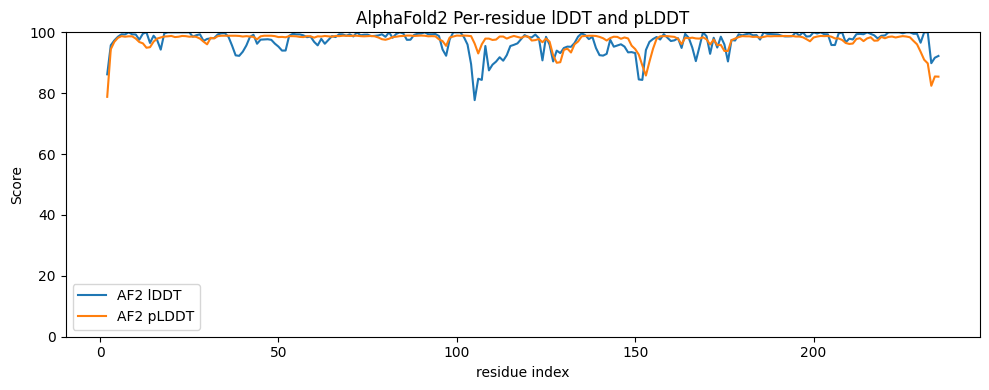

In [111]:
import matplotlib.pyplot as plt

# Filter plddt_AF2 to match the aligned residues
plddt_AF2_for_plot = [plddt_AF2[rid - 1] for rid in res_ids_AF2]

plt.figure(figsize=(10.,4.))
plt.plot(res_ids_AF2, lddt_per_res_AF2*100, label='AF2 lDDT')  # make sure scale in in percent
plt.plot(res_ids_AF2, plddt_AF2_for_plot, label='AF2 pLDDT')

plt.title("AlphaFold2 Per-residue lDDT and pLDDT")
plt.xlabel("residue index")
plt.ylabel("Score")
plt.ylim(0,100)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


In [117]:
from pathlib import Path
import biotite.structure.io.pdbx as pdbx
import biotite.structure.io.pdb as pdb
import os # Import os for directory listing

def cif_to_pdb_biotite(cif_path: str, pdb_path: str, model: int = 1):
    """
    Convert mmCIF to PDB using Biotite.
    model is 1-based (model=1 means first model).
    """
    cif_path = Path(cif_path)
    pdb_path = Path(pdb_path)

    cif_file = pdbx.CIFFile.read(str(cif_path))
    atoms = pdbx.get_structure(cif_file, model=model)

    pdb_file = pdb.PDBFile()
    pdb_file.set_structure(atoms)
    pdb_file.write(str(pdb_path))
    return pdb_path

cif_AF3 = ROOT / "assignment01" / "AlphaFold3" / "fold_9f5m_af3_model_0.cif"
pdb_AF3 = ROOT / "assignment01" / "AlphaFold3" / "fold_9f5m_af3_model_0.pdb"

# --- Diagnostic check for cif_AF3 ---
if not cif_AF3.exists():
    print(f"Error: AlphaFold3 CIF file not found at {cif_AF3}.")
    parent_dir_of_cif = cif_AF3.parent # This should now be the 'AlphaFold3' directory
    if not parent_dir_of_cif.exists():
        print(f"Error: Parent directory {parent_dir_of_cif} does not exist.")
        # Now, check the directory one level up to see what's there
        grandparent_dir = parent_dir_of_cif.parent # This should be 'AlphaFold3'
        if grandparent_dir.exists():
            print(f"Contents of {grandparent_dir}:")
            for item in os.listdir(grandparent_dir):
                print(f"  - {item}")
        else:
            print(f"Error: Grandparent directory {grandparent_dir} does not exist.")
    else:
        print(f"Contents of {parent_dir_of_cif}:")
        for item in os.listdir(parent_dir_of_cif):
            print(f"  - {item}")
    raise FileNotFoundError(f"File not found at {cif_AF3}.")
# --- End Diagnostic check ---

out = cif_to_pdb_biotite(cif_AF3, pdb_AF3, model=1)
print("Wrote:", out)

Wrote: /content/drive/MyDrive/Bioinformatics II/assignment01/AlphaFold3/fold_9f5m_af3_model_0.pdb


/usr/local/lib/python3.12/dist-packages/biotite/structure/io/pdbx/convert.py:461: UserWarning: Attribute 'auth_comp_id' not found within 'atom_site' category. The fallback attribute 'label_comp_id' will be used instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/biotite/structure/io/pdbx/convert.py:461: UserWarning: Attribute 'auth_atom_id' not found within 'atom_site' category. The fallback attribute 'label_atom_id' will be used instead
  warnings.warn(


In [118]:
ref_path   =  model1_pdb     # <-- your experimental PDB
model_path = pdb_AF3   # <-- your predicted PDB

reference = read_pdb_as_atoms(ref_path, model=1)
model     = read_pdb_as_atoms(model_path, model=1)

# --- Build sequences from structures ---
ref_seq   = struc.to_sequence(reference)[0][0]
model_seq = struc.to_sequence(model)[0][0]

# --- Align sequences to find overlap (robust to differing residue numbering) ---
# Use an identity matrix to avoid "creative" substitutions; good for same protein / close homologs
identity = align.SubstitutionMatrix(
    seq.ProteinSequence.alphabet,
    seq.ProteinSequence.alphabet,
    np.eye(len(seq.ProteinSequence.alphabet), dtype=int),
)

aln = align.align_optimal(
    ref_seq,
    model_seq,
    identity,
    gap_penalty=-1,
    terminal_penalty=False,
    max_number=1,
)[0]

# Keep only aligned columns with residue-residue correspondence (drop gaps)
aln = aln[(aln.trace != -1).all(axis=1)]

# Map alignment columns -> residue indices, then -> atom masks
ref_starts   = struc.get_residue_starts(reference)
model_starts = struc.get_residue_starts(model)

ref_mask = struc.get_residue_masks(reference, ref_starts)[aln.trace[:, 0]].any(axis=0)
mod_mask = struc.get_residue_masks(model,     model_starts)[aln.trace[:, 1]].any(axis=0)

reference_olap = reference[ref_mask]
model_olap     = model[mod_mask]

# For lDDT, it's common to use CA atoms (and it matches the common pLDDT interpretation)
ref_ca = reference_olap[reference_olap.atom_name == "CA"]
mod_ca = model_olap[model_olap.atom_name == "CA"]

# --- Per-residue lDDT ---
lddt_per_res_AF3 = struc.lddt(ref_ca, mod_ca, aggregation="residue")
res_ids_AF3 = np.unique(mod_ca.res_id)

print("Per-residue lDDT (first 10):")
for rid, val in list(zip(res_ids_AF3, lddt_per_res_AF3))[:10]:
    print(rid, f"{val:.3f}")

print("AF3 Global lDDT (mean over residues):", float(np.nanmean(lddt_per_res_AF3)))

Per-residue lDDT (first 10):
2 1.000
3 0.984
4 1.000
5 0.996
6 0.997
7 0.997
8 1.000
9 1.000
10 1.000
11 0.996
AF3 Global lDDT (mean over residues): 0.9804375521961646


In [120]:
### 1. Load the per-atom pLDDT values from JSON ########################

import json

json_path = ROOT / "assignment01" / "AlphaFold3" / "fold_9f5m_af3_full_data_0.json" # adjust path as needed

with open(json_path, "r") as f:
    data = json.load(f)
per_atom_plddt_AF3 = data['atom_plddts']

print("Total atoms in JSON:", len(per_atom_plddt_AF3))

### 2. Parse the PDB and collect indices of CA atoms ########################

from Bio.PDB import PDBParser


parser = PDBParser(QUIET=True)
structure = parser.get_structure("af3", str(pdb_AF3))

atoms = list(structure.get_atoms())
print("Total atoms in PDB:", len(atoms))

# Sanity check
assert len(atoms) == len(per_atom_plddt_AF3), \
    "Atom count mismatch between PDB and JSON!"

### 3. Extract pLDDT values for CA atoms only ##################

per_res_plddt_AF3 = []
residue_ids_AF3 = []

for atom, plddt in zip(atoms, per_atom_plddt_AF3):
    if atom.get_name() == "CA":
        per_res_plddt_AF3.append(float(plddt))
        res = atom.get_parent()
        hetflag, resseq, icode = res.get_id()
        residue_ids_AF3.append((resseq, icode.strip()))

print("Number of CA atoms:", len(per_res_plddt_AF3))
print("First 10 CA pLDDT values:", per_res_plddt_AF3[:10])

Total atoms in JSON: 1871
Total atoms in PDB: 1871
Number of CA atoms: 235
First 10 CA pLDDT values: [71.76, 84.85, 95.49, 97.85, 98.47, 98.69, 98.74, 98.86, 98.85, 98.34]


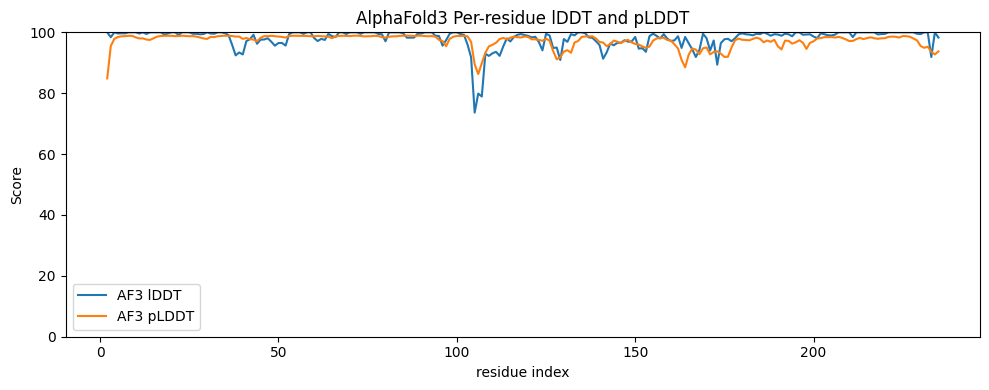

In [121]:
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported

# Filter per_res_plddt_AF3 to match the aligned residues
plddt_AF3_for_plot = [per_res_plddt_AF3[rid - 1] for rid in res_ids_AF3]

plt.figure(figsize=(10.,4.))
plt.plot(res_ids_AF3, lddt_per_res_AF3*100, label='AF3 lDDT')  # make sure scale in in percent
plt.plot(res_ids_AF3, plddt_AF3_for_plot, label='AF3 pLDDT')

plt.title("AlphaFold3 Per-residue lDDT and pLDDT")
plt.xlabel("residue index")
plt.ylabel("Score")
plt.ylim(0,100)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


In [125]:
from Bio.PDB import PDBParser
import pandas as pd
from pathlib import Path
import os

pdb_ESM = ROOT / "assignment01" / "ESMfold" / "esmfold_model.pdb"

# --- Diagnostic check for pdb_ESM ---
if not pdb_ESM.exists():
    print(f"Error: ESMFold PDB file not found at {pdb_ESM}.")
    parent_dir = pdb_ESM.parent
    if parent_dir.exists():
        print(f"Contents of {parent_dir}:")
        for item in os.listdir(parent_dir):
            print(f"  - {item}")
    else:
        print(f"Error: Parent directory {parent_dir} does not exist.")
    raise FileNotFoundError(f"File not found at {pdb_ESM}.")
# --- End Diagnostic check ---

parser = PDBParser(QUIET=True)
structure = parser.get_structure("esm", str(pdb_ESM))

rows = []
for atom in structure.get_atoms():
    if atom.get_name() != "CA":
        continue
    res = atom.get_parent()
    chain = res.get_parent()

    hetflag, resseq, icode = res.get_id()
    rows.append({
        "chain": chain.id,
        "residue_number": int(resseq),
        "insertion_code": icode.strip(),
        "resname": res.get_resname(),
        "pLDDT": float(atom.get_bfactor()),  # <-- B-factor column
    })

df = pd.DataFrame(rows)
print("CA count:", len(df))
df.head()

print(df["pLDDT"].min(), df["pLDDT"].max())  # should be ~0–100

per_res_plddt_ESM = df["pLDDT"].values
res_ids_ESM = df["residue_number"].values

CA count: 235
56.83 98.28


In [127]:
import os

# List the contents of the 'assignment01' directory
assignment_dir = ROOT / "assignment01"

if assignment_dir.exists():
    print(f"Contents of {assignment_dir}:")
    for item in os.listdir(assignment_dir):
        print(f"  - {item}")
else:
    print(f"Error: Directory {assignment_dir} does not exist.")

Contents of /content/drive/MyDrive/Bioinformatics II/assignment01:
  - AlphaFold3
  - ESMfold
  - AlphaFold2


In [128]:
# --- Calculate lDDT for ESMFold ---

# Ensure model1_pdb is the reference path
ref_path = model1_pdb
model_path = pdb_ESM # pdb_ESM was defined in cell Su9BeQOFgmEo

reference_esm = read_pdb_as_atoms(ref_path, model=1)
model_esm     = read_pdb_as_atoms(model_path, model=1)

# --- Build sequences from structures ---
ref_seq_esm   = struc.to_sequence(reference_esm)[0][0]
model_seq_esm = struc.to_sequence(model_esm)[0][0]

# --- Align sequences to find overlap (robust to differing residue numbering) ---
identity_esm = align.SubstitutionMatrix(
    seq.ProteinSequence.alphabet,
    seq.ProteinSequence.alphabet,
    np.eye(len(seq.ProteinSequence.alphabet), dtype=int),
)
aln_esm = align.align_optimal(
    ref_seq_esm,
    model_seq_esm,
    identity_esm,
    gap_penalty=-1,
    terminal_penalty=False,
    max_number=1,
)[0]

# Keep only aligned columns with residue-residue correspondence (drop gaps)
aln_esm = aln_esm[(aln_esm.trace != -1).all(axis=1)]

# Map alignment columns -> residue indices, then -> atom masks
ref_starts_esm   = struc.get_residue_starts(reference_esm)
model_starts_esm = struc.get_residue_starts(model_esm)

ref_mask_esm = struc.get_residue_masks(reference_esm, ref_starts_esm)[aln_esm.trace[:, 0]].any(axis=0)
mod_mask_esm = struc.get_residue_masks(model_esm,     model_starts_esm)[aln_esm.trace[:, 1]].any(axis=0)

reference_olap_esm = reference_esm[ref_mask_esm]
model_olap_esm     = model_esm[mod_mask_esm]

# For lDDT, it's common to use CA atoms
ref_ca_esm = reference_olap_esm[reference_olap_esm.atom_name == "CA"]
mod_ca_esm = model_olap_esm[model_olap_esm.atom_name == "CA"]

# --- Per-residue lDDT ---
lddt_per_res_ESM = struc.lddt(ref_ca_esm, mod_ca_esm, aggregation="residue")
res_ids_ESM_lddt = np.unique(mod_ca_esm.res_id)

print("ESMFold Per-residue lDDT (first 10):")
for rid, val in list(zip(res_ids_ESM_lddt, lddt_per_res_ESM))[:10]:
    print(rid, f"{val:.3f}")

print("ESMFold Global lDDT (mean over residues):", float(np.nanmean(lddt_per_res_ESM)))


ESMFold Per-residue lDDT (first 10):
2 0.836
3 0.973
4 0.977
5 0.989
6 0.994
7 1.000
8 0.993
9 0.990
10 1.000
11 1.000
ESMFold Global lDDT (mean over residues): 0.9567719323526862


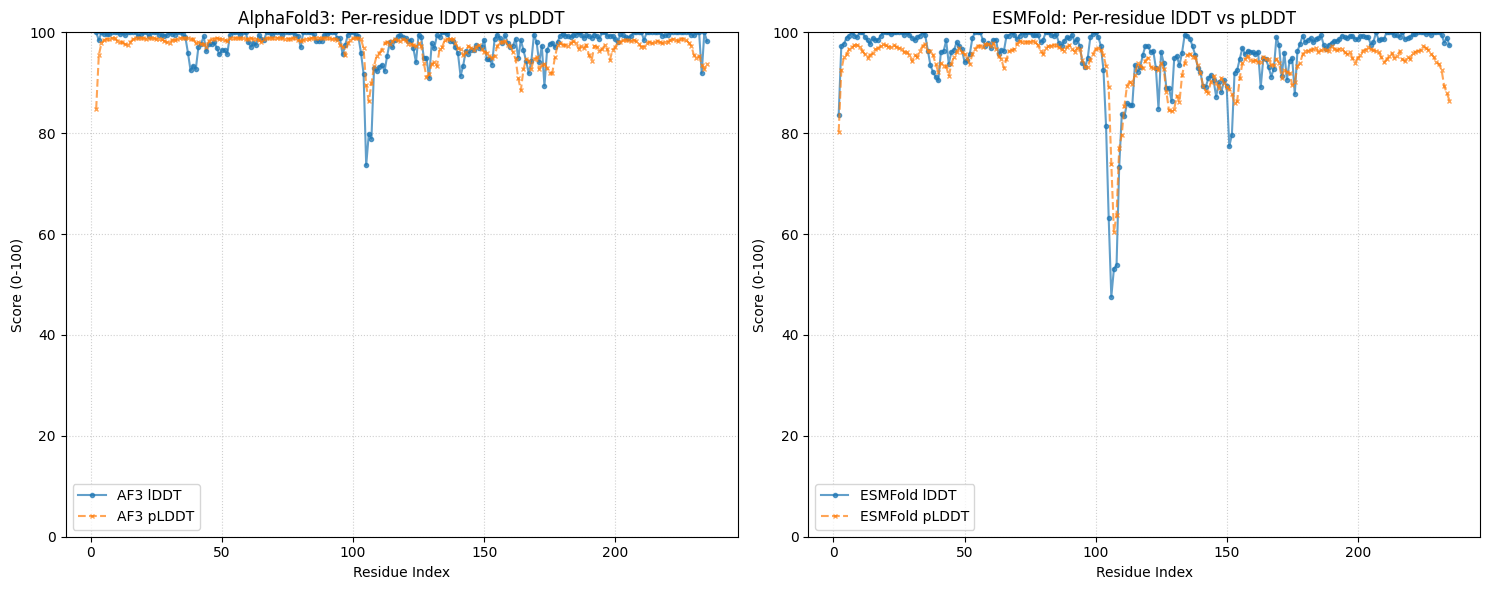

In [129]:
import matplotlib.pyplot as plt
import numpy as np

# Filter per_res_plddt_ESM to match the aligned residues for lDDT
plddt_ESM_for_plot = [per_res_plddt_ESM[rid - 1] for rid in res_ids_ESM_lddt]

plt.figure(figsize=(15, 6))

# --- AlphaFold3 Plot ---
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(res_ids_AF3, lddt_per_res_AF3 * 100, label='AF3 lDDT', marker='o', linestyle='-', markersize=3, alpha=0.7)
plt.plot(res_ids_AF3, plddt_AF3_for_plot, label='AF3 pLDDT', marker='x', linestyle='--', markersize=3, alpha=0.7)
plt.title("AlphaFold3: Per-residue lDDT vs pLDDT")
plt.xlabel("Residue Index")
plt.ylabel("Score (0-100)")
plt.ylim(0, 100)
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)

# --- ESMFold Plot ---
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(res_ids_ESM_lddt, lddt_per_res_ESM * 100, label='ESMFold lDDT', marker='o', linestyle='-', markersize=3, alpha=0.7)
plt.plot(res_ids_ESM_lddt, plddt_ESM_for_plot, label='ESMFold pLDDT', marker='x', linestyle='--', markersize=3, alpha=0.7)
plt.title("ESMFold: Per-residue lDDT vs pLDDT")
plt.xlabel("Residue Index")
plt.ylabel("Score (0-100)")
plt.ylim(0, 100)
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


In [130]:
ref_path   =  model1_pdb     # <-- your experimental PDB
model_path = pdb_ESM   # <-- your predicted PDB

reference = read_pdb_as_atoms(ref_path, model=1)
model     = read_pdb_as_atoms(model_path, model=1)

# --- Build sequences from structures ---
ref_seq   = struc.to_sequence(reference)[0][0]
model_seq = struc.to_sequence(model)[0][0]

# --- Align sequences to find overlap (robust to differing residue numbering) ---
# Use an identity matrix to avoid "creative" substitutions; good for same protein / close homologs
identity = align.SubstitutionMatrix(
    seq.ProteinSequence.alphabet,
    seq.ProteinSequence.alphabet,
    np.eye(len(seq.ProteinSequence.alphabet), dtype=int),
)

aln = align.align_optimal(
    ref_seq,
    model_seq,
    identity,
    gap_penalty=-1,
    terminal_penalty=False,
    max_number=1,
)[0]

# Keep only aligned columns with residue-residue correspondence (drop gaps)
aln = aln[(aln.trace != -1).all(axis=1)]

# Map alignment columns -> residue indices, then -> atom masks
ref_starts   = struc.get_residue_starts(reference)
model_starts = struc.get_residue_starts(model)

ref_mask = struc.get_residue_masks(reference, ref_starts)[aln.trace[:, 0]].any(axis=0)
mod_mask = struc.get_residue_masks(model,     model_starts)[aln.trace[:, 1]].any(axis=0)

reference_olap = reference[ref_mask]
model_olap     = model[mod_mask]

# For lDDT, it's common to use CA atoms (and it matches the common pLDDT interpretation)
ref_ca = reference_olap[reference_olap.atom_name == "CA"]
mod_ca = model_olap[model_olap.atom_name == "CA"]

# --- Per-residue lDDT ---
lddt_per_res_ESM = struc.lddt(ref_ca, mod_ca, aggregation="residue")
res_ids_ESM = np.unique(mod_ca.res_id)

print("Per-residue lDDT (first 10):")
for rid, val in list(zip(res_ids_ESM, lddt_per_res_ESM))[:10]:
    print(rid, f"{val:.3f}")

print("ESMFold Global lDDT (mean over residues):", float(np.nanmean(lddt_per_res_ESM)))

Per-residue lDDT (first 10):
2 0.836
3 0.973
4 0.977
5 0.989
6 0.994
7 1.000
8 0.993
9 0.990
10 1.000
11 1.000
ESMFold Global lDDT (mean over residues): 0.9567719323526862


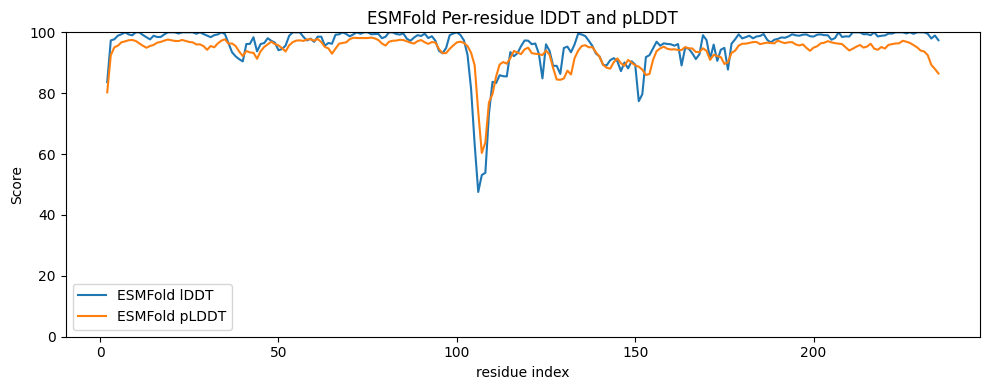

In [131]:
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported

# Filter per_res_plddt_ESM to match the aligned residues for lDDT
plddt_ESM_for_plot = [per_res_plddt_ESM[rid - 1] for rid in res_ids_ESM]

plt.figure(figsize=(10.,4.))
plt.plot(res_ids_ESM, lddt_per_res_ESM*100, label='ESMFold lDDT')  # make sure scale in in percent
plt.plot(res_ids_ESM, plddt_ESM_for_plot, label='ESMFold pLDDT')

plt.title("ESMFold Per-residue lDDT and pLDDT")
plt.xlabel("residue index")
plt.ylabel("Score")
plt.ylim(0,100)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


In [132]:
import pandas as pd
import numpy as np

# Calculate mean values
mean_lddt_af2 = np.nanmean(lddt_per_res_AF2)
mean_plddt_af2 = np.nanmean(plddt_AF2_for_plot)

mean_lddt_af3 = np.nanmean(lddt_per_res_AF3)
mean_plddt_af3 = np.nanmean(plddt_AF3_for_plot)

mean_lddt_esm = np.nanmean(lddt_per_res_ESM)
mean_plddt_esm = np.nanmean(plddt_ESM_for_plot)

# Create a DataFrame for comparison
summary_data = {
    'Metric': ['Mean lDDT (Experimental Accuracy)', 'Mean pLDDT (Predicted Confidence)'],
    'AlphaFold2': [mean_lddt_af2 * 100, mean_plddt_af2],
    'AlphaFold3': [mean_lddt_af3 * 100, mean_plddt_af3],
    'ESMFold': [mean_lddt_esm * 100, mean_plddt_esm]
}

summary_df = pd.DataFrame(summary_data)

print("\nSummary of Mean lDDT and pLDDT Values (0-100 scale):")
display(summary_df)



Summary of Mean lDDT and pLDDT Values (0-100 scale):


,Metric,AlphaFold2,AlphaFold3,ESMFold
0,Mean lDDT (Experimental Accuracy),97.171057,98.043755,95.677193
1,Mean pLDDT (Predicted Confidence),97.432350,97.220385,94.009017


In [133]:
print("Summary statistics for ESMFold DataFrame 'df':")
display(df.describe())


Summary statistics for ESMFold DataFrame 'df':


,residue_number,pLDDT
count,235.000000,235.000000
mean,118.000000,93.850809
std,67.982841,5.310609
min,1.000000,56.830000
25%,59.500000,93.260000
50%,118.000000,95.330000
75%,176.500000,96.675000
max,235.000000,98.280000


In [134]:
print("res_ids_AF2 (AlphaFold2 lDDT residue IDs):")
print(res_ids_AF2)
print(f"Length of res_ids_AF2: {len(res_ids_AF2)}")

print("\nres_ids_ESM (ESMFold lDDT residue IDs):")
print(res_ids_ESM)
print(f"Length of res_ids_ESM: {len(res_ids_ESM)}")


res_ids_AF2 (AlphaFold2 lDDT residue IDs):
[  2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19
  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37
  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55
  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73
  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91
  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109
 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127
 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145
 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163
 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181
 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199
 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217
 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235]
Length 

In [135]:
print("--- AlphaFold2 Residue IDs and pLDDT values ---")
for i, (rid, plddt) in enumerate(zip(res_ids_AF2, plddt_AF2_for_plot)):
    print(f"Residue: {rid}, pLDDT: {plddt:.2f}")
    if i >= 19: # Print first 20 for brevity
        print("... (truncated) ...")
        break

print("\n--- ESMFold Residue IDs and pLDDT values ---")
for i, (rid, plddt) in enumerate(zip(res_ids_ESM_lddt, plddt_ESM_for_plot)):
    print(f"Residue: {rid}, pLDDT: {plddt:.2f}")
    if i >= 19: # Print first 20 for brevity
        print("... (truncated) ...")
        break


--- AlphaFold2 Residue IDs and pLDDT values ---
Residue: 2, pLDDT: 78.81
Residue: 3, pLDDT: 94.44
Residue: 4, pLDDT: 96.88
Residue: 5, pLDDT: 98.19
Residue: 6, pLDDT: 98.75
Residue: 7, pLDDT: 98.56
Residue: 8, pLDDT: 98.69
Residue: 9, pLDDT: 98.69
Residue: 10, pLDDT: 97.94
Residue: 11, pLDDT: 96.81
Residue: 12, pLDDT: 96.38
Residue: 13, pLDDT: 94.94
Residue: 14, pLDDT: 95.12
Residue: 15, pLDDT: 96.94
Residue: 16, pLDDT: 97.94
Residue: 17, pLDDT: 98.31
Residue: 18, pLDDT: 98.62
Residue: 19, pLDDT: 98.69
Residue: 20, pLDDT: 98.81
Residue: 21, pLDDT: 98.44
... (truncated) ...

--- ESMFold Residue IDs and pLDDT values ---
Residue: 2, pLDDT: 80.28
Residue: 3, pLDDT: 92.48
Residue: 4, pLDDT: 95.08
Residue: 5, pLDDT: 95.64
Residue: 6, pLDDT: 96.74
Residue: 7, pLDDT: 97.02
Residue: 8, pLDDT: 97.41
Residue: 9, pLDDT: 97.49
Residue: 10, pLDDT: 97.16
Residue: 11, pLDDT: 96.36
Residue: 12, pLDDT: 95.61
Residue: 13, pLDDT: 94.94
Residue: 14, pLDDT: 95.52
Residue: 15, pLDDT: 95.85
Residue: 16, pLDDT

In [136]:
import numpy as np

# --- AlphaFold2 Correlation ---
# Ensure both are numpy arrays for corrcoef
corr_AF2 = np.corrcoef(np.array(plddt_AF2_for_plot), lddt_per_res_AF2 * 100)[0, 1]
print(f"Pearson Correlation (pLDDT vs lDDT) for AlphaFold2: {corr_AF2:.4f}")

# --- AlphaFold3 Correlation ---
corr_AF3 = np.corrcoef(np.array(plddt_AF3_for_plot), lddt_per_res_AF3 * 100)[0, 1]
print(f"Pearson Correlation (pLDDT vs lDDT) for AlphaFold3: {corr_AF3:.4f}")

# --- ESMFold Correlation ---
# Ensure both are numpy arrays for corrcoef
corr_ESM = np.corrcoef(np.array(plddt_ESM_for_plot), lddt_per_res_ESM * 100)[0, 1]
print(f"Pearson Correlation (pLDDT vs lDDT) for ESMFold: {corr_ESM:.4f}")


Pearson Correlation (pLDDT vs lDDT) for AlphaFold2: 0.4746
Pearson Correlation (pLDDT vs lDDT) for AlphaFold3: 0.5617
Pearson Correlation (pLDDT vs lDDT) for ESMFold: 0.8488


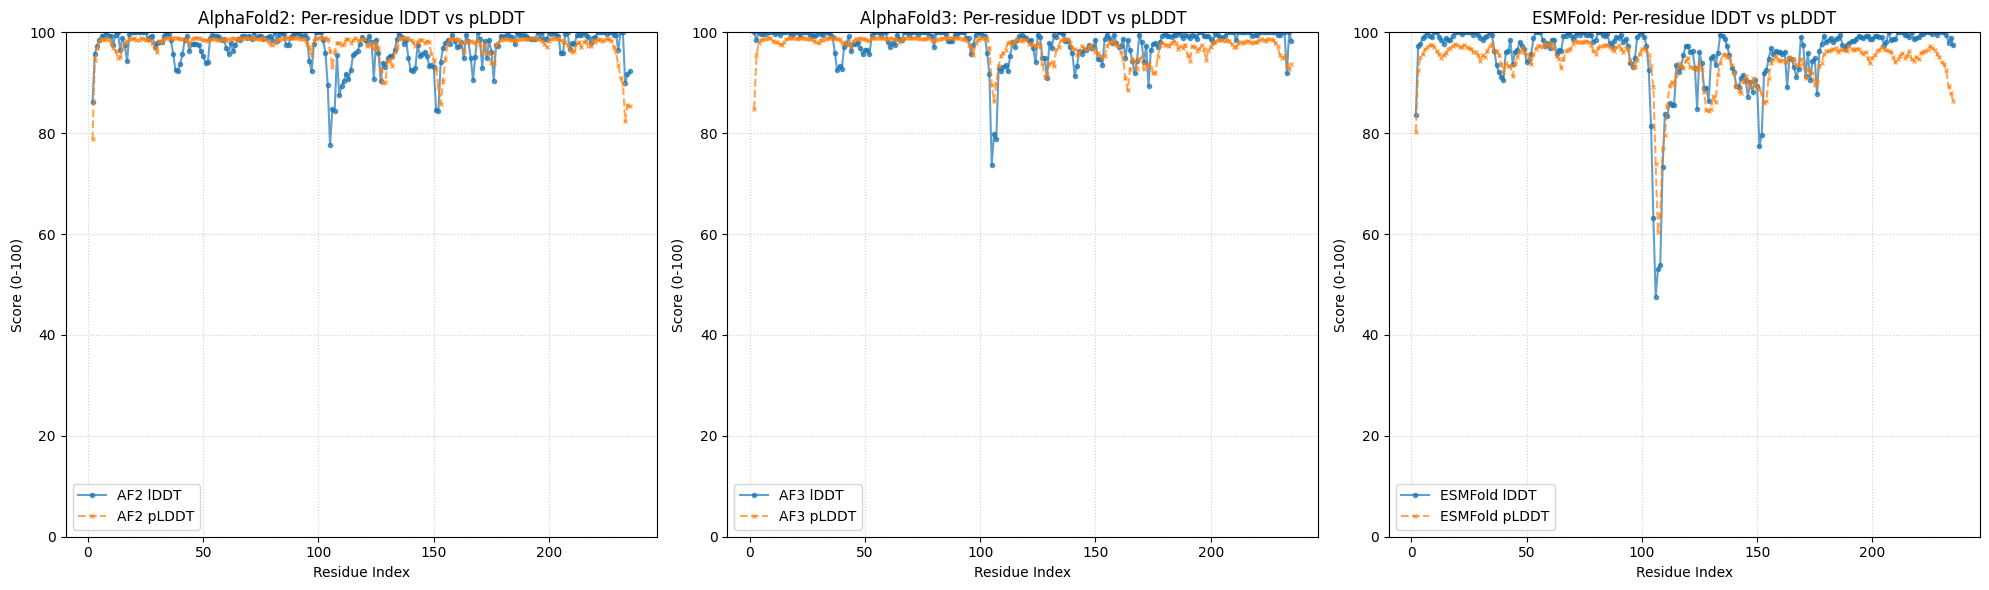

In [137]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(20, 6))

# --- AlphaFold2 Plot ---
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
plt.plot(res_ids_AF2, lddt_per_res_AF2 * 100, label='AF2 lDDT', marker='o', linestyle='-', markersize=3, alpha=0.7)
plt.plot(res_ids_AF2, plddt_AF2_for_plot, label='AF2 pLDDT', marker='x', linestyle='--', markersize=3, alpha=0.7)
plt.title("AlphaFold2: Per-residue lDDT vs pLDDT")
plt.xlabel("Residue Index")
plt.ylabel("Score (0-100)")
plt.ylim(0, 100)
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)

# --- AlphaFold3 Plot ---
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
plt.plot(res_ids_AF3, lddt_per_res_AF3 * 100, label='AF3 lDDT', marker='o', linestyle='-', markersize=3, alpha=0.7)
plt.plot(res_ids_AF3, plddt_AF3_for_plot, label='AF3 pLDDT', marker='x', linestyle='--', markersize=3, alpha=0.7)
plt.title("AlphaFold3: Per-residue lDDT vs pLDDT")
plt.xlabel("Residue Index")
plt.ylabel("Score (0-100)")
plt.ylim(0, 100)
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)

# --- ESMFold Plot ---
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
plt.plot(res_ids_ESM_lddt, lddt_per_res_ESM * 100, label='ESMFold lDDT', marker='o', linestyle='-', markersize=3, alpha=0.7)
plt.plot(res_ids_ESM_lddt, plddt_ESM_for_plot, label='ESMFold pLDDT', marker='x', linestyle='--', markersize=3, alpha=0.7)
plt.title("ESMFold: Per-residue lDDT vs pLDDT")
plt.xlabel("Residue Index")
plt.ylabel("Score (0-100)")
plt.ylim(0, 100)
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


In [138]:
display(summary_df)

,Metric,AlphaFold2,AlphaFold3,ESMFold
0,Mean lDDT (Experimental Accuracy),97.171057,98.043755,95.677193
1,Mean pLDDT (Predicted Confidence),97.432350,97.220385,94.009017
